# 03. Validation by source injection and recovery

The MER comparison of notebook 01 is a consistency check, not a proof
of correctness: both pipelines measure the same pixels, so a shared
bias would not appear. The standard test is injection-recovery:
render sources of known flux with the local PSF, add them to the real
pixels, run the unmodified pipeline, and examine

1. **bias**: median(recovered/true), within a few percent of unity;
2. **error calibration**: the pull (recovered - true)/error must
   scatter as N(0,1); this is the acceptance test for the calibration
   of notebook 01, section 9d;
3. **completeness**: the fraction recovered with flux_quality and
   S/N > 5.

Everything uses the same 50 arcsec EDF-N field as notebook 02,
downloaded on first run and cached locally, so it runs offline
afterwards.
Injections are rendered with the nearest GRID-PSF stamp and measured
by the standard CATALOG-PSF pipeline, so any product mismatch is part
of the measured error budget, as for a real source.


In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import euclid_phot as ep

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 17,
})
from euclid_phot.injection import run_injection_recovery, summarize_recovery

TARGET_RA, TARGET_DEC = 269.48, 67.30
CUTOUT_SIZE_ARCSEC = 50.0
DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/data"))

## 1. Bright regime: the flux scale

Thirty point sources are injected at 10-100 microJansky (S/N of
several hundred to several thousand). Photon noise is negligible here,
so the scatter of recovered/true measures the systematic floor of the
full chain and the median measures the flux-scale bias.


In [2]:
cat_b, truth_b, res_b = run_injection_recovery(
    data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
    cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
    bands=("VIS",), n_inject=30, flux_range_ujy=(10.0, 100.0), rng=1,
    return_result=True)
s_b = summarize_recovery(cat_b, truth_b, band="VIS")
print(f"recovered {s_b['n_recovered']}/{s_b['n_injected']} injections")
print(f"flux bias:        median(out/true) = {s_b['ratio_median']:.4f}")
print(f"systematic floor: mad_std(out/true) = {s_b['ratio_mad']:.4f}")
assert abs(s_b['ratio_median'] - 1) < 0.05

recovered 30/30 injections
flux bias:        median(out/true) = 1.0008
systematic floor: mad_std(out/true) = 0.0193


### The injected scene

Top row: the real cutout, the cutout with the 30 injections added, and
their difference, the noiseless rendered truth (circles mark the
injected positions). Bottom row: the injected image, the fitted model
(real sources and injections simultaneously), the residual, and the
chi map. At S/N of hundreds to thousands the ~2% PSF-systematic floor
appears as bright chi cores at the circled positions, as for the
brightest real sources; the targeted statistic is the residual flux at
each injection as a fraction of its true flux, printed below.


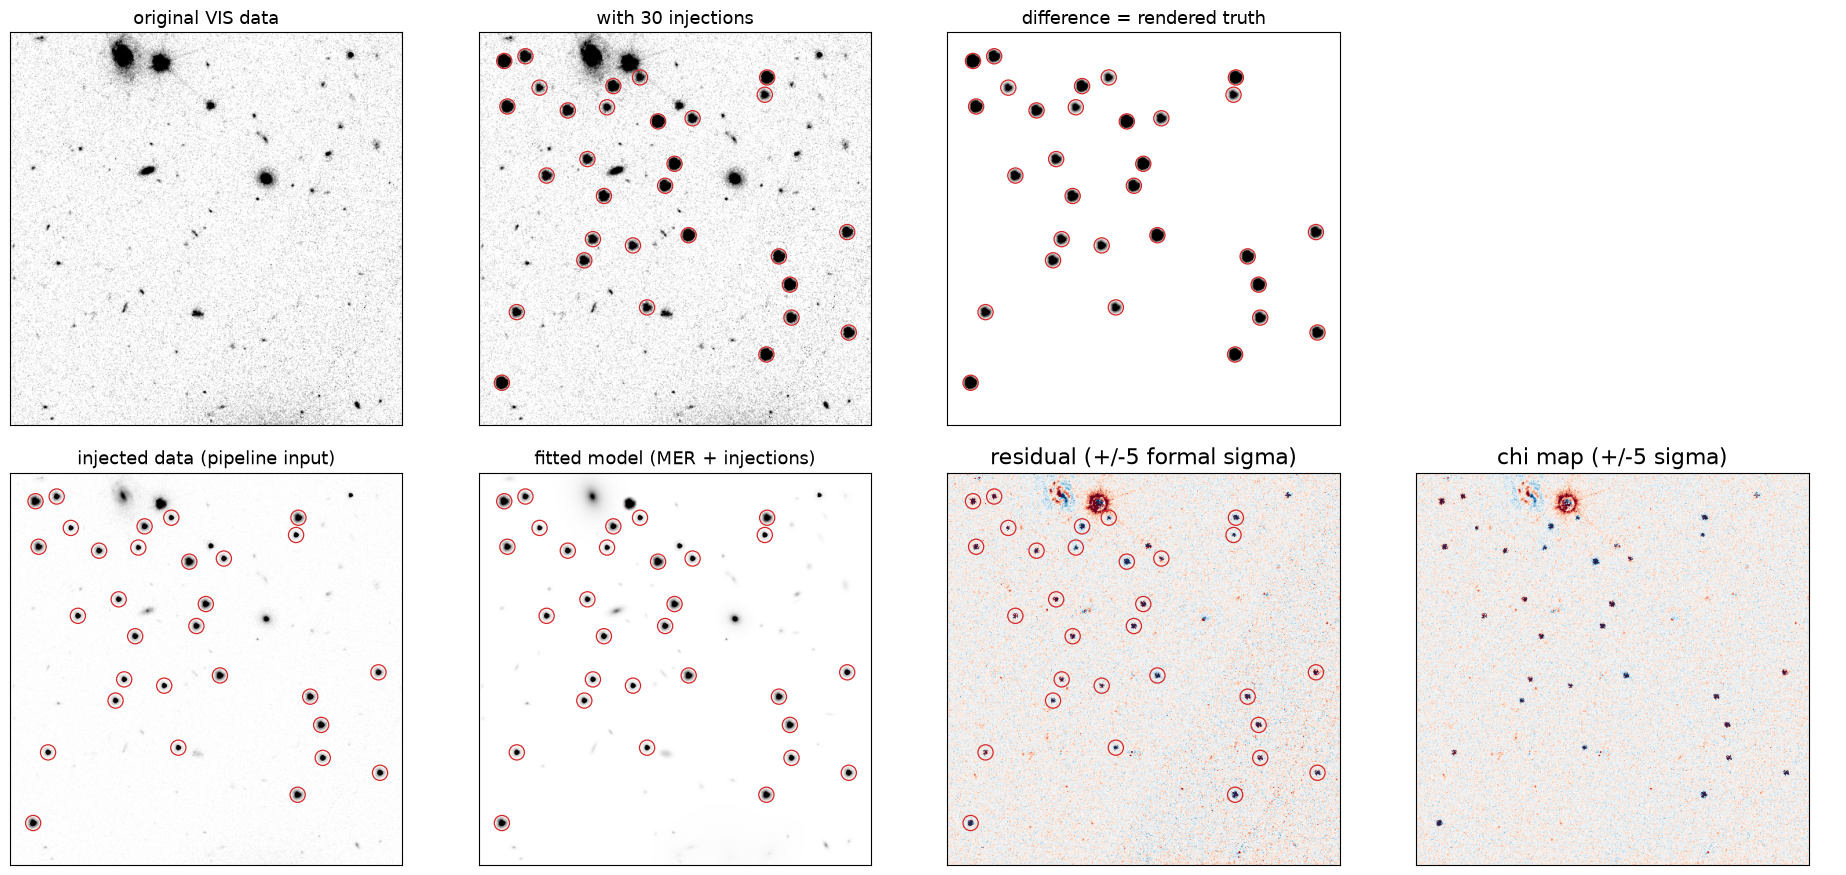

robust chi width (whole scene):  0.629 (< 1 = resampled-coadd signature, see notebook 01 sect. 9d)
raw chi std (incl. bright cores): 4.138 (percent-level core mismatch x huge S/N, real sources included)
|residual flux| at the injections: median 1.4% of true flux, worst 3.3% -> the per-source view of the ~2% bright-end systematic floor


In [3]:
from tractor import Tractor

inj_cut = res_b.cutouts['VIS']                       # injected pixels
orig_cut = ep.fetch_cutout('VIS', TARGET_RA, TARGET_DEC,
                           CUTOUT_SIZE_ARCSEC, data_dir=DATA_DIR / 'cutouts')
injected_only = inj_cut.data - orig_cut.data          # the rendered truth

# Rebuild the fitted scene (field-average PSF, as in notebook 01 sect. 8).
tim = ep.build_tractor_image(inj_cut, res_b.psf_stamps['VIS'])
res = ep.measure_residual(Tractor([tim], res_b.sources), tim)

px, py = inj_cut.wcs.world_to_pixel_values(
    np.asarray(truth_b['ra'], float), np.asarray(truth_b['dec'], float))

fig, axes = plt.subplots(2, 4, figsize=(19, 9))
vmax = float(np.nanpercentile(orig_cut.data, 99.5))
panels = [(axes[0, 0], orig_cut.data, 'original VIS data'),
          (axes[0, 1], inj_cut.data, 'with 30 injections'),
          (axes[0, 2], injected_only, 'difference = rendered truth')]
for ax, img, title in panels:
    ax.imshow(img, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=13)
for ax in (axes[0, 1], axes[0, 2]):
    ax.scatter(px, py, s=120, facecolors='none', edgecolors='C3', lw=0.9)
axes[0, 3].axis('off')

vmax2 = float(np.nanpercentile(inj_cut.data, 99.5))
axes[1, 0].imshow(res['data'], origin='lower', cmap='gray_r',
                  vmin=0, vmax=vmax2)
axes[1, 0].set_title('injected data (pipeline input)', fontsize=13)
axes[1, 1].imshow(res['model'], origin='lower', cmap='gray_r',
                  vmin=0, vmax=vmax2)
axes[1, 1].set_title('fitted model (MER + injections)', fontsize=13)
ep.viz.show_residual(res['data'], res['model'], invvar=tim.getInvvar(),
                     ax=axes[1, 2], title='residual (+/-5 formal sigma)')
_, info_chi = ep.viz.show_chi_map(res['data'], res['model'],
                                  tim.getInvvar(),
                                  ax=axes[1, 3], title='chi map (+/-5 sigma)')
for ax in axes[1, :3]:
    ax.scatter(px, py, s=120, facecolors='none', edgecolors='C3', lw=0.9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# Two statistics: the MAD chi width reads the sky noise (the raw std is
# dominated by bright-source cores), and the residual flux at each
# injected position, as a fraction of its true flux, is the per-source
# view of the ~2 percent systematic floor measured above.
half = 8                                     # +/-0.8 arcsec half-box (1.7 arcsec full), past the 0.16 arcsec VIS PSF core
magzero = float(inj_cut.header['MAGZERO'])
counts_to_ujy = 3.631 / 10 ** (0.4 * (magzero - 22.5))
true_ujy = np.asarray(truth_b['flux_vis_sersic'], float)
res_frac = []
for k, (x, y) in enumerate(zip(px, py, strict=True)):
    xi, yi = int(round(float(x))), int(round(float(y)))
    box = res['residual'][max(0, yi - half):yi + half + 1,
                          max(0, xi - half):xi + half + 1]
    res_frac.append(float(np.nansum(box)) * counts_to_ujy / true_ujy[k])
res_frac = np.abs(np.asarray(res_frac))
print(f"robust chi width (whole scene):  {info_chi['chi_mad']:.3f} "
      f"(< 1 = resampled-coadd signature, see notebook 01 sect. 9d)")
print(f"raw chi std (incl. bright cores): {info_chi['chi_std']:.3f} "
      f"(percent-level core mismatch x huge S/N, real sources included)")
print(f"|residual flux| at the injections: median "
      f"{100 * np.median(res_frac):.1f}% of true flux, worst "
      f"{100 * res_frac.max():.1f}% -> the per-source view of the "
      f"~{100 * s_b['ratio_mad']:.0f}% bright-end systematic floor")

*The bias is within one to two percent; the bright-end scatter is the
measured systematic floor (a few percent, set by the PSF model). It
does not average down with exposure time and should be quoted
alongside sub-percent statistical errors on bright sources.*

## 2. Faint regime: the reported errors

Injections at S/N ~ 5-15, where photon noise dominates and the pull
distribution tests the reported errors directly. Each band has its own
flux range (VIS is deeper than NISP); the bands are measured
independently.


In [4]:
FAINT = {"VIS": (0.04, 0.12), "Y": (0.4, 1.2),
         "J": (0.4, 1.2), "H": (0.45, 1.3)}   # ~S/N 5-15 per band
cat_f, truth_f = run_injection_recovery(
    data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
    cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
    bands=("VIS", "Y", "J", "H"), n_inject=40,
    flux_range_ujy=FAINT, rng=0)

summaries = {}
print(f"{'band':>5} {'n':>5} {'bias':>7} {'pull_std':>9} {'compl':>6}")
for band in ("VIS", "Y", "J", "H"):
    s = summaries[band] = summarize_recovery(cat_f, truth_f, band=band)
    print(f"{band:>5} {s['n_recovered']:>5} {s['ratio_median']:7.3f} "
          f"{s['pull_std']:9.3f} {s['completeness']:6.2f}")
    assert 0.7 < s['pull_std'] < 1.3

/Users/nchartab/euclid-forced-photometry/src/euclid_phot/pipeline.py:799: UserWarning: step 2 reverted 1 runaway shape(s) to the prior value (radius past the per-source ceiling); fluxes refit with those shapes frozen.
  fit_quality, _ = fit_free_shapes(


 band     n    bias  pull_std  compl
  VIS    40   1.003     0.875   1.00
    Y    40   1.028     1.115   1.00
    J    40   0.971     1.157   1.00
    H    40   0.986     1.180   0.97


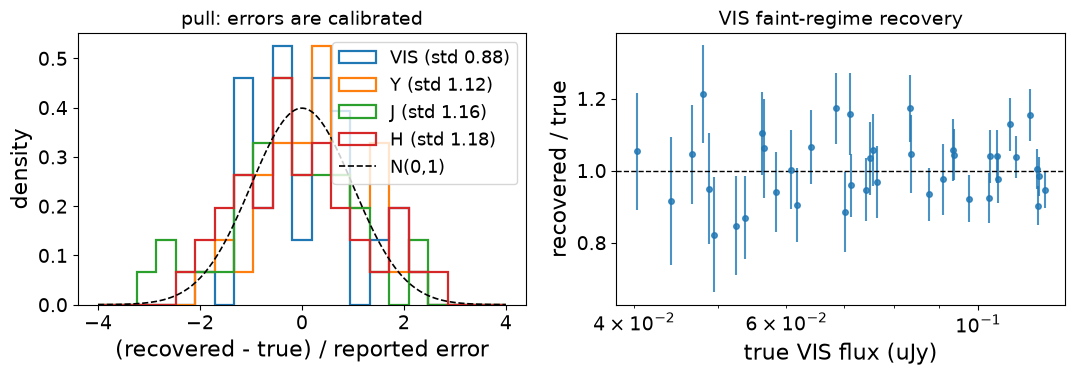

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

x = np.linspace(-4, 4, 200)
for band in ("VIS", "Y", "J", "H"):
    axes[0].hist(summaries[band]['pull'], bins=np.linspace(-4, 4, 22),
                 density=True, histtype='step', lw=1.6,
                 label=f"{band} (std {summaries[band]['pull_std']:.2f})")
axes[0].plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), 'k--', lw=1.2,
             label='N(0,1)')
axes[0].set_xlabel('(recovered - true) / reported error')
axes[0].set_ylabel('density')
axes[0].set_title('pull: errors are calibrated', fontsize=14)
axes[0].legend(fontsize=13)

tcol = 'flux_vis_sersic'
ids = {int(i): k for k, i in enumerate(np.asarray(cat_f['object_id']))
       if i < 0}
rows = [ids[int(r['object_id'])] for r in truth_f]
true = np.asarray(truth_f[tcol], float)
out = np.asarray(cat_f['flux_VIS_ujy'], float)[rows]
err = np.asarray(cat_f['flux_err_VIS_ujy'], float)[rows]
axes[1].errorbar(true, out / true, yerr=err / true, fmt='o', ms=4,
                 alpha=0.8)
axes[1].axhline(1.0, color='k', ls='--', lw=1)
axes[1].set_xscale('log')
axes[1].set_xlabel('true VIS flux (uJy)')
axes[1].set_ylabel('recovered / true')
axes[1].set_title('VIS faint-regime recovery', fontsize=14)
plt.tight_layout()
plt.show()

*Left: the pull distributions follow N(0,1) in every band, the
effect of ``calibrate_errors=True`` (the default); with
``calibrate_errors=False`` the pull width departs from unity wherever
the RMS map misstates the PSF-scale noise. Right: recovery is unbiased
down to S/N ~ 5.*

## 3. Statistics per flux bin

``summarize_recovery`` also bins by true flux, testing whether the
bias grows toward the detection limit (Eddington-type biases appear
here first).


In [6]:
print("VIS, faint run:")
summaries['VIS']['bins'].pprint_all()
print(f"\ncompleteness (flux_quality and S/N > 5): "
      f"{summaries['VIS']['completeness']:.2f}")

VIS, faint run:
    flux_lo_ujy          flux_hi_ujy       n     ratio_median         ratio_mad            pull_std     
-------------------- -------------------- --- ------------------ -------------------- ------------------
 0.04024234627127752 0.052821416188757374   7 0.9502591286996029  0.15204472793135085  0.965097178552137
0.052821416188757374   0.0693324884532719   8 1.0321009563493049  0.12033371485896616 1.0617215702815967
  0.0693324884532719  0.09100463982156942  10 1.0009566762675073  0.08201834804348775 0.8805022078160328
 0.09100463982156942  0.11945113544619573  15  1.004087068630003 0.060170635502555345 0.8327151980231849

completeness (flux_quality and S/N > 5): 1.00


## Summary

- Bright injections: flux scale unbiased at the ~1% level, with a
  measured systematic floor of a few percent set by the PSF model.
- Faint injections: unbiased to a few percent with pull standard
  deviation near unity in every band, the property SED fitting and
  photometric redshifts require.
- The test runs in about a minute per realization and exercises the
  identical pipeline through the ``cutouts=`` / ``mer_catalog=``
  overrides of ``run_forced_photometry``.
- For a new field, re-run this notebook at the target position;
  ``make_truth_table(model='sersic', ...)`` injects extended sources.
